<a href="https://colab.research.google.com/github/marcosvpm1708/Computa-o-de-baixo-desempenho/blob/Prophet/Prophet_Model_CAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

# --- Passo 1: Carregamento e Análise ---
print("--- PASSO 1: Carregando e Analisando o seu Dataset ---")

# O nome do arquivo Excel que você mencionou
# ATENÇÃO: Use o nome exato do arquivo .xlsx que está na sua pasta
file_path = 'atlasbdexcel.xlsx'

# Tentar carregar o arquivo Excel
try:
    df_atlas = pd.read_excel(file_path)
    print(f"Arquivo '{file_path}' carregado com sucesso como um arquivo Excel.")
except FileNotFoundError:
    print(f"ERRO: O arquivo '{file_path}' não foi encontrado. Verifique o nome e se ele está na mesma pasta do script.")
except Exception as e:
    print(f"Ocorreu um erro ao ler o arquivo Excel: {e}")


# --- Teste do Passo 1 (continua igual) ---
# O restante do código de verificação não precisa de alteração

# Verifique se o df_atlas foi carregado antes de prosseguir
if 'df_atlas' in locals():
    print("\n--- Verificação Inicial dos Dados ---\n\n")

    # 1. Informações gerais do DataFrame
    print("Formato do DataFrame (info):\n")
    df_atlas.info()

    # 2. Visualizar as primeiras linhas para entender os valores
    print("\nPrimeiras 5 linhas do DataFrame (head):")
    print(df_atlas.head())

    # 3. Listar os nomes exatos das colunas
    print("\nNomes das Colunas:")
    print(df_atlas.columns)

    # 4. Verificar os valores únicos de colunas importantes
    print("\nValores únicos em 'Região':")
    print(df_atlas['regiao'].unique())

    print("\nValores únicos em 'Grupo de Desastre':")
    print(df_atlas['grupo_de_desastre'].unique())

--- PASSO 1: Carregando e Analisando o seu Dataset ---
Arquivo 'atlasbdexcel.xlsx' carregado com sucesso como um arquivo Excel.

--- Verificação Inicial dos Dados ---


Formato do DataFrame (info):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67230 entries, 0 to 67229
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Nome_Municipio       67230 non-null  object        
 1   Sigla_UF             67230 non-null  object        
 2   regiao               67230 non-null  object        
 3   Data_Evento          67230 non-null  datetime64[ns]
 4   descricao_tipologia  67230 non-null  object        
 5   grupo_de_desastre    67230 non-null  object        
dtypes: datetime64[ns](1), object(5)
memory usage: 3.1+ MB

Primeiras 5 linhas do DataFrame (head):
   Nome_Municipio Sigla_UF regiao Data_Evento descricao_tipologia  \
0    Salto Veloso       SC    Sul  1991-01-07     Estiagem e Seca   


--- PASSO 2: Preparando os dados para o Prophet ---
Filtrando para 'Região SUDESTE' e 'Grupo de Desastre HIDROLÓGICO'...
Convertendo a coluna 'Data do Evento' para o tipo data...
Agregando o número de eventos por dia...
Renomeando colunas para 'ds' e 'y'...

--- Verificação dos Dados Preparados ---
Formato do DataFrame para o Prophet (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12023 entries, 0 to 12022
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      12023 non-null  datetime64[ns]
 1   y       12023 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 188.0 KB

Exemplo de dias com maior ocorrência de desastres (histórico):
              ds    y
2169  1997-01-07  152
11303 2022-01-10   84
11302 2022-01-09   78
11301 2022-01-08   73
4754  2004-02-05   65


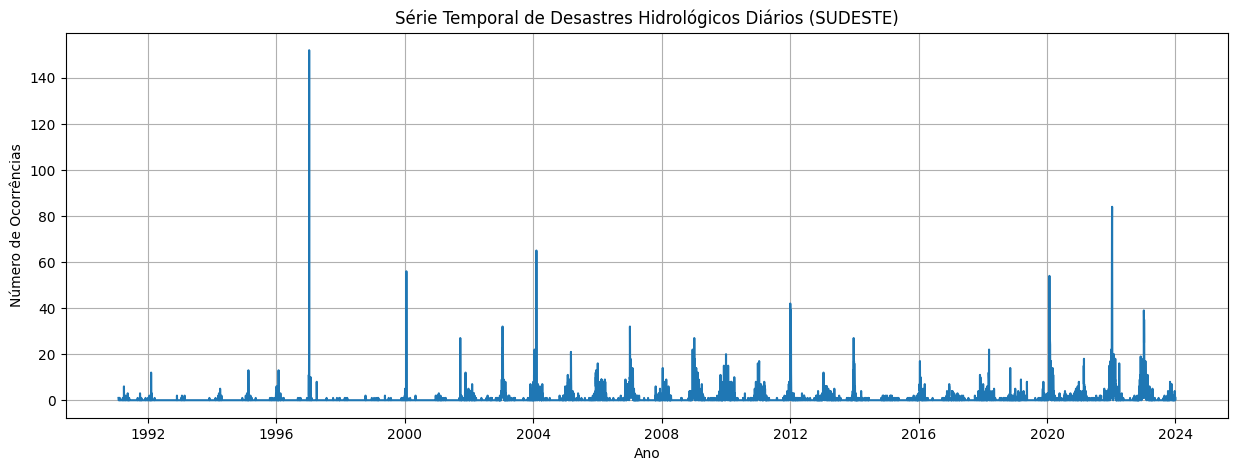

In [ ]:
# --- Passo 2: Preparação e Agregação ---
print("\n--- PASSO 2: Preparando os dados para o Prophet ---")

# 1. Filtrar os dados para o nosso cenário
print("Filtrando para 'Região SUDESTE' e 'Grupo de Desastre HIDROLÓGICO'...")
df_filtrado = df_atlas[
    (df_atlas['regiao'] == 'Sudeste') &
    (df_atlas['grupo_de_desastre'] == 'Hidrológico')
].copy()

# 2. Converter a coluna de data para o formato datetime
# O formato parece ser Dia/Mês/Ano. Usamos `dayfirst=True`.
# `errors='coerce'` transformará datas inválidas em NaT (Not a Time), que podemos remover.
print("Convertendo a coluna 'Data do Evento' para o tipo data...")
df_filtrado['data_formatada'] = pd.to_datetime(df_filtrado['Data_Evento'], dayfirst=True, errors='coerce')
df_filtrado.dropna(subset=['data_formatada'], inplace=True) # Remove linhas onde a data era inválida

# 3. Agregar os dados: Contar o número de eventos por dia
print("Agregando o número de eventos por dia...")
df_agregado = df_filtrado.set_index('data_formatada').resample('D').size().reset_index(name='contagem')

# 4. Renomear as colunas para o formato do Prophet ('ds' e 'y')
print("Renomeando colunas para 'ds' e 'y'...")
df_prophet = df_agregado.rename(columns={'data_formatada': 'ds', 'contagem': 'y'})


# --- Teste do Passo 2 ---
print("\n--- Verificação dos Dados Preparados ---")
print("Formato do DataFrame para o Prophet (info):")
df_prophet.info()

print("\nExemplo de dias com maior ocorrência de desastres (histórico):")
print(df_prophet.sort_values(by='y', ascending=False).head())

# Teste Visual: Plotar a série temporal agregada
plt.figure(figsize=(15, 5))
plt.plot(df_prophet['ds'], df_prophet['y'])
plt.title('Série Temporal de Desastres Hidrológicos Diários (SUDESTE)')
plt.xlabel('Ano')
plt.ylabel('Número de Ocorrências')
plt.grid(True)
plt.show()

DEBUG:cmdstanpy:input tempfile: /tmp/tmp3r89mpu6/m41rt1vl.json



--- PASSO 3: Treinamento, Previsão e Classificação ---
Instanciando e treinando o modelo Prophet...


DEBUG:cmdstanpy:input tempfile: /tmp/tmp3r89mpu6/69soyss3.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=15839', 'data', 'file=/tmp/tmp3r89mpu6/m41rt1vl.json', 'init=/tmp/tmp3r89mpu6/69soyss3.json', 'output', 'file=/tmp/tmp3r89mpu6/prophet_modeltkhx4bfg/prophet_model-20250526221350.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:13:50 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:13:53 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Criando datas futuras e realizando a previsão para 365 dias...

--- Verificação da Previsão Numérica ---
Visualizando o final da previsão (últimos 5 dias):
              ds      yhat  yhat_lower  yhat_upper
12383 2024-12-25  3.905665    0.282923    7.417972
12384 2024-12-26  4.102579    0.402886    7.882610
12385 2024-12-27  4.236295    0.354477    7.967828
12386 2024-12-28  4.152600    0.572646    7.792579
12387 2024-12-29  4.299282    0.699315    8.289365
Gerando gráficos da previsão e componentes...


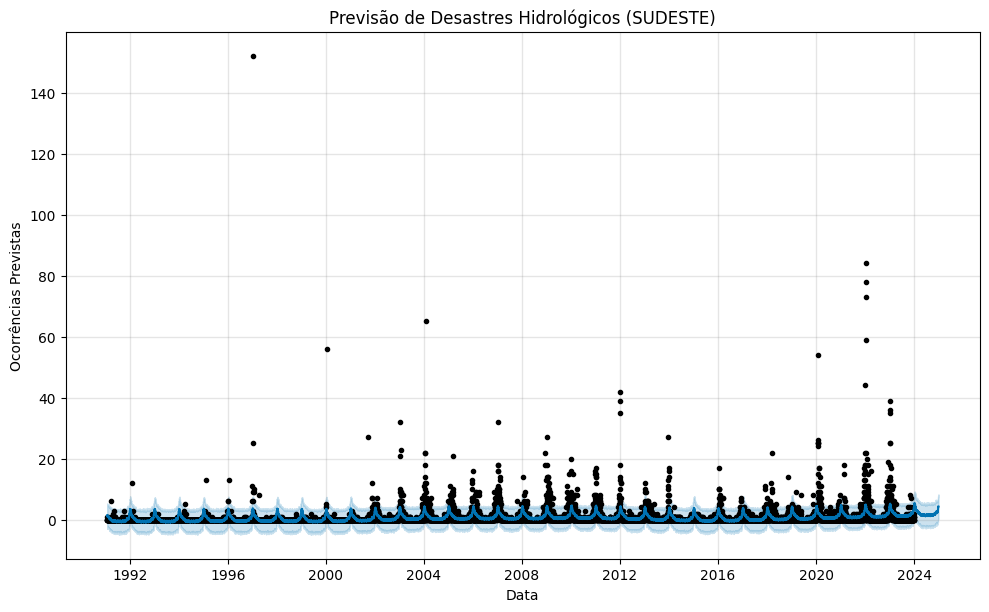

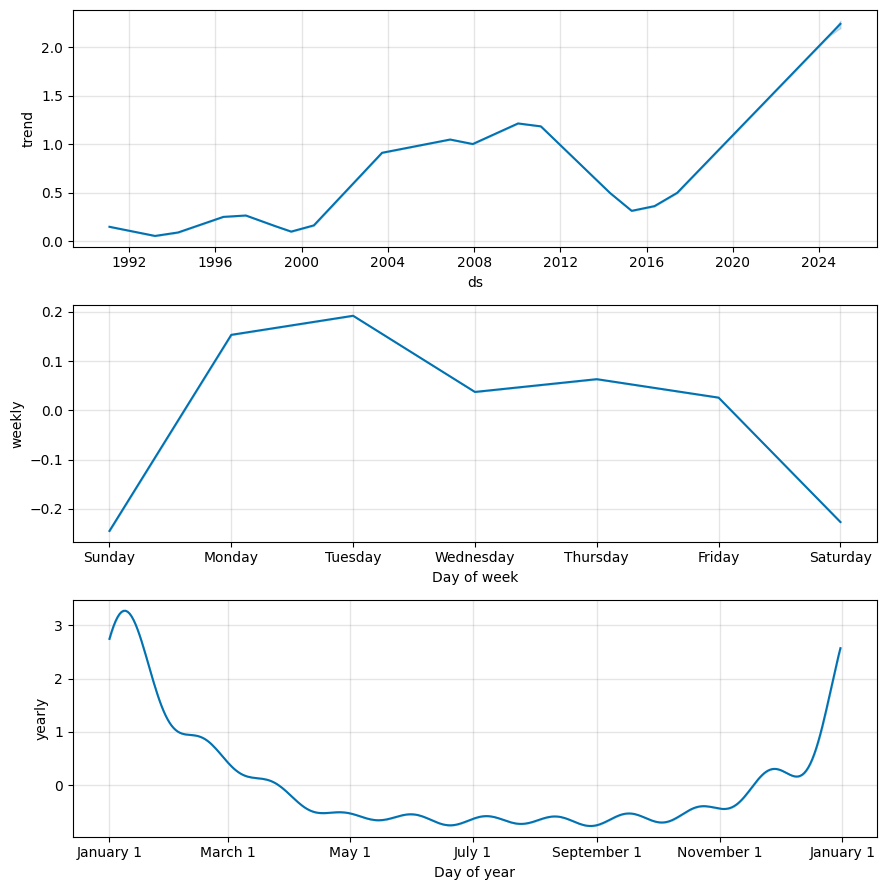


--- Classificando a Previsão em Níveis de Risco ---
Limiar para Risco Médio (Quantil 90%): 2.00 eventos/dia
Limiar para Risco Alto (Quantil 99%): 11.00 eventos/dia

--- Verificação da Classificação de Risco ---
Contagem de dias por nível de risco para o próximo ano:
Nivel_Risco
Baixo    231
Médio    134
Name: count, dtype: int64

Exemplo de dias previstos com Risco Alto:
Empty DataFrame
Columns: [ds, yhat, Nivel_Risco]
Index: []

Gerando gráfico do calendário de risco...


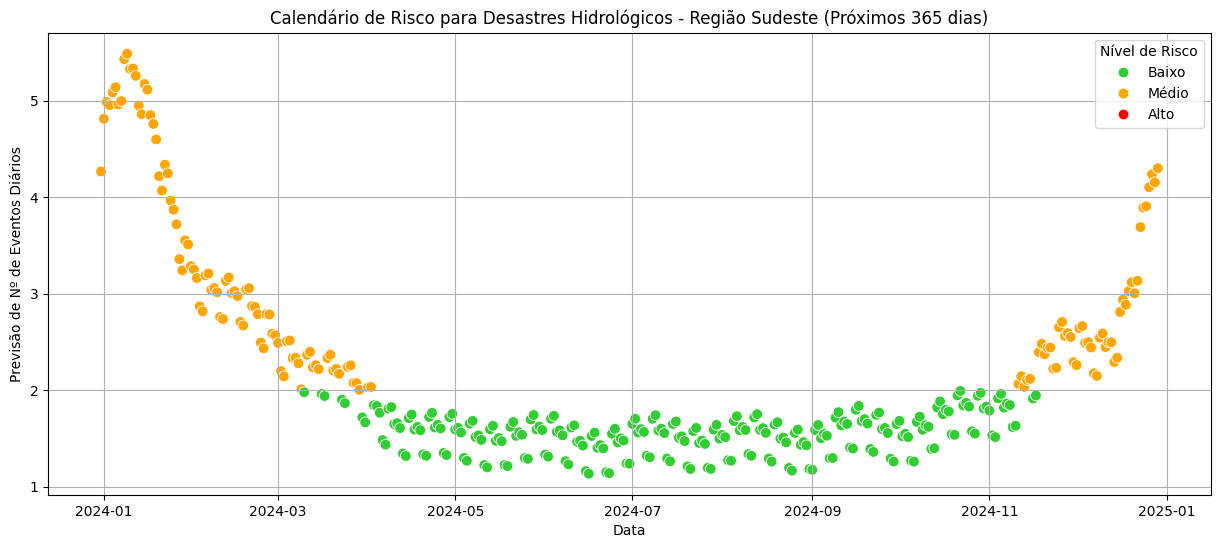

In [ ]:
# --- Passo 3: Treinamento, Previsão e Classificação ---
print("\n--- PASSO 3: Treinamento, Previsão e Classificação ---")

# 1. Instanciar e Treinar o Modelo Prophet
print("Instanciando e treinando o modelo Prophet...")
# Sazonalidade anual é crucial para desastres hidrológicos (estações chuvosas)
modelo = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
modelo.fit(df_prophet)

# 2. Criar Datas Futuras e Realizar a Previsão
print("Criando datas futuras e realizando a previsão para 365 dias...")
futuro = modelo.make_future_dataframe(periods=365)
previsao = modelo.predict(futuro)

# --- Teste da Previsão ---
print("\n--- Verificação da Previsão Numérica ---")
print("Visualizando o final da previsão (últimos 5 dias):")
print(previsao[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

# Plotar a previsão e os componentes
print("Gerando gráficos da previsão e componentes...")
fig1 = modelo.plot(previsao)
plt.title('Previsão de Desastres Hidrológicos (SUDESTE)')
plt.xlabel('Data')
plt.ylabel('Ocorrências Previstas')
plt.show()

fig2 = modelo.plot_components(previsao)
plt.show()


# --- Classificação de Risco ---
print("\n--- Classificando a Previsão em Níveis de Risco ---")

# 1. Definir limiares com base nos dados históricos
# Usaremos os quantis para uma definição mais realista
limiar_medio = df_prophet['y'].quantile(0.90)
limiar_alto = df_prophet['y'].quantile(0.99)

print(f"Limiar para Risco Médio (Quantil 90%): {limiar_medio:.2f} eventos/dia")
print(f"Limiar para Risco Alto (Quantil 99%): {limiar_alto:.2f} eventos/dia")

# 2. Criar a função de classificação
def classificar_risco(yhat):
    yhat = max(0, yhat)
    if yhat >= limiar_alto:
        return 'Alto'
    elif yhat >= limiar_medio:
        return 'Médio'
    else:
        return 'Baixo'

# 3. Aplicar a classificação na parte futura da previsão
previsao_futura = previsao[previsao['ds'] > df_prophet['ds'].max()].copy()
previsao_futura['Nivel_Risco'] = previsao_futura['yhat'].apply(classificar_risco)

# --- Teste Final da Classificação ---
print("\n--- Verificação da Classificação de Risco ---")
print("Contagem de dias por nível de risco para o próximo ano:")
print(previsao_futura['Nivel_Risco'].value_counts())

print("\nExemplo de dias previstos com Risco Alto:")
print(previsao_futura[previsao_futura['Nivel_Risco'] == 'Alto'][['ds', 'yhat', 'Nivel_Risco']].head())


# Teste Visual Final: Calendário de Risco
print("\nGerando gráfico do calendário de risco...")
plt.figure(figsize=(15, 6))
sns.scatterplot(
    data=previsao_futura,
    x='ds',
    y='yhat',
    hue='Nivel_Risco',
    hue_order=['Baixo', 'Médio', 'Alto'],
    palette={'Baixo': 'limegreen', 'Médio': 'orange', 'Alto': 'red'},
    s=60
)
plt.title('Calendário de Risco para Desastres Hidrológicos - Região Sudeste (Próximos 365 dias)')
plt.xlabel('Data')
plt.ylabel('Previsão de Nº de Eventos Diários')
plt.grid(True)
plt.legend(title='Nível de Risco')
plt.show()